# Renewable Energy Forecasting – API Notebook

This notebook shows how to use the project code as a small "API" for:
- Loading the raw solar dataset
- Building time-based features
- Creating a time-aware train/validation split
- Training a baseline model and generating predictions

The goal is to demonstrate **reusable functions** from `RenewableEnergy_utils.py` that can be
called from notebooks, scripts, or other projects.


In [2]:
import sys

# Install scikit-learn in this Jupyter environment
!{sys.executable} -m pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 107.0 MB/s eta 0:00:00a 0:00:01


In [4]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Figure out where we are and where the project root is
NOTEBOOK_DIR = Path.cwd().resolve()

# If this notebook lives in the project root, we expect RenewableEnergy_utils.py to be here.
# If it lives in a subfolder (like notebooks/ or examples/), the project root is the parent.
if (NOTEBOOK_DIR / "RenewableEnergy_utils.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR
else:
    PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_PATH = DATA_DIR / "raw" / "solar_energy.csv"

# Make sure Python can see RenewableEnergy_utils.py
sys.path.append(str(PROJECT_ROOT))

from RenewableEnergy_utils import (
    load_data,
    make_basic_time_features,
    train_val_split,
    TIME_COL,
    TARGET_COL,
)

PROJECT_ROOT, RAW_PATH


(PosixPath('/work/class_project/MSML610/Fall2025/projects/UmdTask15_Fall2025_Renewable_Energy_Production'),
 PosixPath('/work/class_project/MSML610/Fall2025/projects/UmdTask15_Fall2025_Renewable_Energy_Production/data/raw/solar_energy.csv'))

## 1. Using the command-line API

Here I expose a very simple API that wraps the existing command-line entry points.  
A user who just wants to generate features and train the baseline model can call these functions instead of running shell commands manually.


In [5]:
def run_baseline_forecast(
    raw_path: Path = RAW_PATH,
    test_size_days: int = 7,
    rf_kwargs: dict = None,
):
    """
    High-level helper that:
    - Loads the raw solar dataset
    - Builds time-based features
    - Creates a time-aware train/validation split
    - Trains a Random Forest model
    - Returns metrics and predictions
    """
    if rf_kwargs is None:
        rf_kwargs = {
            "n_estimators": 200,
            "random_state": 42,
            "n_jobs": -1,
        }

    # 1. Load raw data
    df_raw = load_data(str(raw_path))

    # 2. Build features
    df_feats = make_basic_time_features(df_raw)

    # 3. Train/validation split
    X_train, X_val, y_train, y_val, feature_cols = train_val_split(
        df_feats,
        test_size_days=test_size_days,
    )

    # 4. Train model
    model = RandomForestRegressor(**rf_kwargs)
    model.fit(X_train, y_train)

    # 5. Predict and compute metrics
    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = mean_squared_error(y_val, y_pred, squared=False)

    results = {
        "model": model,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "y_pred": y_pred,
        "feature_cols": feature_cols,
        "mae": mae,
        "rmse": rmse,
    }
    return results


In [6]:
results = run_baseline_forecast()

print(f"Validation MAE : {results['mae']:.4f}")
print(f"Validation RMSE: {results['rmse']:.4f}")
print("\nNumber of validation points:", len(results["y_val"]))
print("Feature columns:", results["feature_cols"])


Validation MAE : 0.3972
Validation RMSE: 0.5188

Number of validation points: 168
Feature columns: ['temp_c', 'cloud_cover', 'solar_radiation', 'wind_speed', 'hour', 'dayofweek', 'month', 'energy_mwh_lag_1', 'energy_mwh_lag_2', 'energy_mwh_lag_24', 'energy_mwh_rollmean_3', 'energy_mwh_rollmean_24']


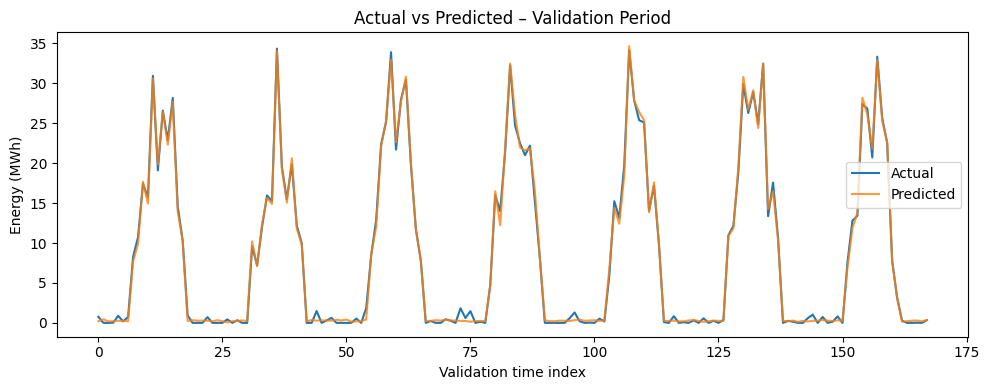

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(results["y_val"].values, label="Actual")
plt.plot(results["y_pred"], label="Predicted", alpha=0.8)
plt.xlabel("Validation time index")
plt.ylabel("Energy (MWh)")
plt.title("Actual vs Predicted – Validation Period")
plt.legend()
plt.tight_layout()
plt.show()


## Summary: How to Use the Project API

In this notebook, I treated the project code as a small "API" made of reusable functions:

- `load_data(path)` loads the raw hourly solar dataset from CSV.
- `make_basic_time_features(df)` adds calendar features (hour, day of week, month) and lag/rolling
  features for `energy_mwh`.
- `train_val_split(df_feats, test_size_days=7)` creates a time-aware train/validation split so that
  the most recent days are used for validation.
- `run_baseline_forecast(...)` (defined in this notebook) calls all of the above functions,
  trains a Random Forest model, and returns a dictionary with:
  - the trained model object
  - train and validation feature matrices
  - true and predicted validation targets
  - error metrics (MAE and RMSE)
  - the list of feature column names

This shows how someone could import `RenewableEnergy_utils.py` from another notebook or script and
quickly spin up a baseline forecast, without re-implementing the data loading, feature engineering,
or splitting logic.
